In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.load_criteo import load_counts
from src.stats_tests import two_proportion_test
from src.corrections import apply_correction, correction_summary, compare_methods
from src.power import achieved_power

# 03 Hypothesis Tests

The sanity checks passed in notebook 02. Only now are we allowed to read the
outcomes.

In [2]:
counts = load_counts()

n_c = int(counts["n_control"])
n_t = int(counts["n_treatment"])

criteo_raw = {
    "conversion": two_proportion_test(
        successes_control=int(counts["conversion_control"]), n_control=n_c,
        successes_treatment=int(counts["conversion_treatment"]), n_treatment=n_t,
    ),
    "visit": two_proportion_test(
        successes_control=int(counts["visit_control"]), n_control=n_c,
        successes_treatment=int(counts["visit_treatment"]), n_treatment=n_t,
    ),
}

summary = pd.DataFrame([
    {
        "metric": m,
        "control": f"{r['rate_control']:.4%}",
        "treatment": f"{r['rate_treatment']:.4%}",
        "abs_lift": f"{r['absolute_lift']:+.4%}",
        "rel_lift": f"{r['relative_lift']:+.1%}",
        "ci_95_relative": f"[{r['ci_relative'][0]:+.1%}, {r['ci_relative'][1]:+.1%}]",
        "p_value": f"{r['p_value']:.3e}",
    }
    for m, r in criteo_raw.items()
])
summary

,metric,control,treatment,abs_lift,rel_lift,ci_95_relative,p_value
0,conversion,0.1938%,0.3089%,+0.1152%,+59.4%,"[+56.0%, +62.9%]",7.308e-179
1,visit,3.8201%,4.8543%,+1.0342%,+27.1%,"[+26.3%, +27.8%]",0.000e+00


## The p value has stopped being informative

Look at those p values. At fourteen million users, almost any real effect will be
significant, and a p value that small is not telling us the effect is large, it is
telling us the sample is enormous.

This is the point where a lot of analyses go wrong. They report significance,
everyone nods, and nobody asks how big the effect actually is. The relative lift
and its interval are the finding. The p value is now just a formality confirming
that the direction is not noise.

In [3]:
criteo_corrected = apply_correction(criteo_raw, method="fdr_bh", alpha=0.05)
pd.DataFrame(correction_summary(criteo_corrected))

,metric,p_raw,p_adjusted,significant_before,significant_after,changed
0,conversion,0.0,0.0,True,True,False
1,visit,0.0,0.0,True,True,False


In [4]:
df = pd.read_parquet("../data/processed/simulated_onboarding.parquet")

METRICS = ["account_funded", "kyc_completed", "support_ticket_raised"]
control = df[df["group"] == "control"]
treatment = df[df["group"] == "treatment"]

sim_raw = {
    m: two_proportion_test(
        successes_control=int(control[m].sum()), n_control=len(control),
        successes_treatment=int(treatment[m].sum()), n_treatment=len(treatment),
    )
    for m in METRICS
}

sim_corrected = apply_correction(sim_raw, method="fdr_bh", alpha=0.05)
pd.DataFrame(correction_summary(sim_corrected))

,metric,p_raw,p_adjusted,significant_before,significant_after,changed
0,account_funded,0.000000,0.000000,True,True,False
1,kyc_completed,0.009299,0.013949,True,True,False
2,support_ticket_raised,0.885458,0.885458,False,False,False


## What the correction changed

Read the "changed" column. Any True in it is a result that a naive analysis would
have reported as real and that does not survive once we account for having run
three tests.

That is the exact moment a wrong decision gets made, and it is invisible unless
you go looking for it.

In [5]:
comparison = compare_methods(sim_raw, alpha=0.05)

rows = []
for method, results in comparison.items():
    for metric, r in results.items():
        rows.append({
            "method": method,
            "metric": metric,
            "p_adjusted": r["p_adjusted"],
            "significant": r["significant"],
        })

pivot = pd.DataFrame(rows).pivot(index="metric", columns="method", values="p_adjusted")
print("Adjusted p values under three corrections:")
print()
print(pivot.round(5))
print()
print("Bonferroni is the most conservative and Benjamini Hochberg the least.")
print("We chose BH because with a small family and one metric that genuinely")
print("matters, Bonferroni spends power on secondaries we do not need certainty")
print("about, and that power comes out of the primary metric we do.")

Adjusted p values under three corrections:

method                 bonferroni   fdr_bh     holm
metric                                             
account_funded             0.0000  0.00000  0.00000
kyc_completed              0.0279  0.01395  0.01860
support_ticket_raised      1.0000  0.88546  0.88546

Bonferroni is the most conservative and Benjamini Hochberg the least.
We chose BH because with a small family and one metric that genuinely
matters, Bonferroni spends power on secondaries we do not need certainty
about, and that power comes out of the primary metric we do.


In [6]:
primary = sim_corrected["account_funded"]

power_got = achieved_power(
    n_control=len(control),
    n_treatment=len(treatment),
    baseline_rate=primary["rate_control"],
    target_rate=primary["rate_control"] * 1.06,
)

print(f"Power to detect the 6 percent MDE with the sample we collected: {power_got:.1%}")
print()
print("Report this whether the result is positive or null. If the result is null")
print("and the power is low, we have learned nothing, and saying so is the")
print("difference between an honest report and a misleading one.")

Power to detect the 6 percent MDE with the sample we collected: 99.4%

Report this whether the result is positive or null. If the result is null
and the power is low, we have learned nothing, and saying so is the
difference between an honest report and a misleading one.


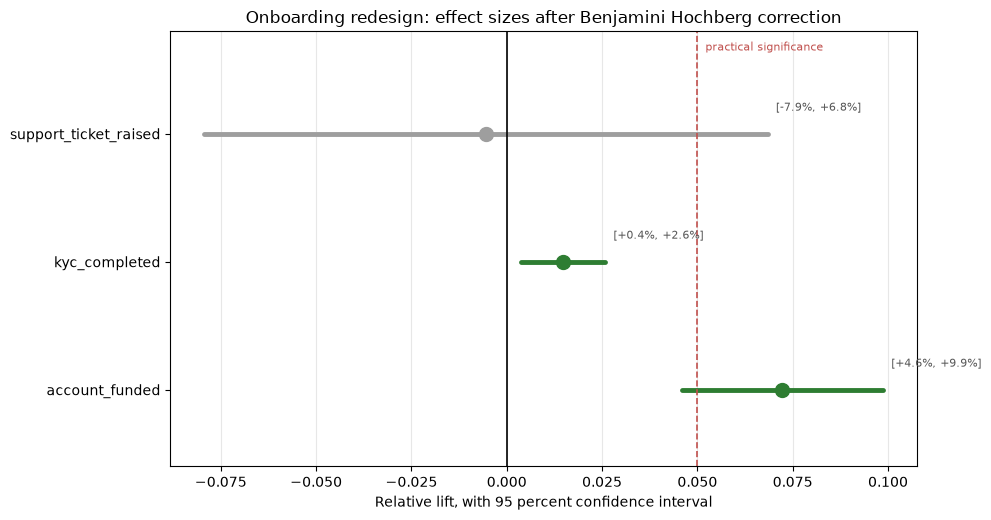

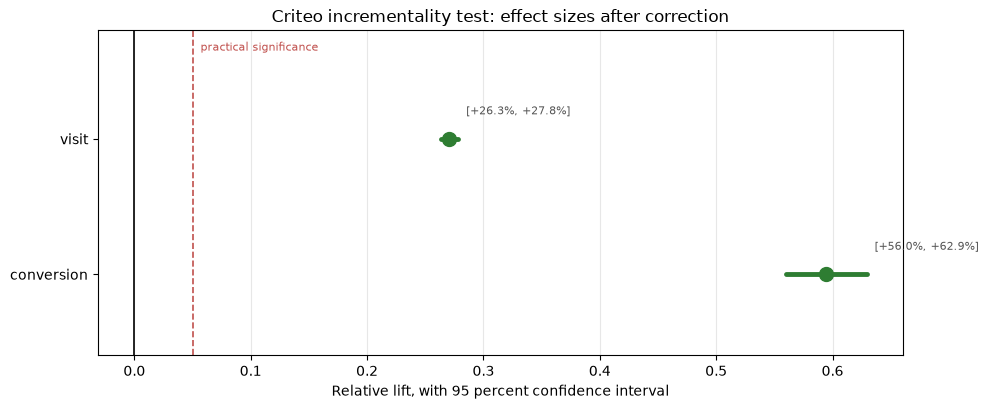

In [7]:
def forest_plot(corrected, metrics, title, threshold=0.05, filename=None):
    fig, ax = plt.subplots(figsize=(10, 1.1 * len(metrics) + 2))

    for y, m in enumerate(metrics):
        r = corrected[m]
        lo, hi = r["ci_relative"]
        colour = "#2e7d32" if r["significant_adjusted"] else "#9e9e9e"
        ax.plot([lo, hi], [y, y], color=colour, linewidth=3.5, solid_capstyle="round")
        ax.plot(r["relative_lift"], y, "o", color=colour, markersize=10)
        ax.text(hi, y + 0.18, f"  [{lo:+.1%}, {hi:+.1%}]", fontsize=8, color="#555555")

    ax.axvline(0, color="black", linewidth=1.2)
    ax.axvline(threshold, color="#c0504d", linestyle="--", linewidth=1.2)
    ax.text(threshold, len(metrics) - 0.35,
            "  practical significance", fontsize=8, color="#c0504d")

    ax.set_yticks(range(len(metrics)))
    ax.set_yticklabels(metrics)
    ax.set_ylim(-0.6, len(metrics) - 0.2)
    ax.set_xlabel("Relative lift, with 95 percent confidence interval")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150)
    plt.show()


forest_plot(sim_corrected, METRICS,
            "Onboarding redesign: effect sizes after Benjamini Hochberg correction",
            filename="../reports/figures/03_forest_simulated.png")

forest_plot(criteo_corrected, ["conversion", "visit"],
            "Criteo incrementality test: effect sizes after correction",
            filename="../reports/figures/03_forest_criteo.png")